In [35]:
import scqubits as scq
import numpy as np
import matplotlib.pyplot as plt
from qutip import *
from scqubits.core.discretization import Grid1d

from scipy.special import factorial

# SC Qubit Analysis

Spectral data:   0%|          | 0/201 [00:00<?, ?it/s]

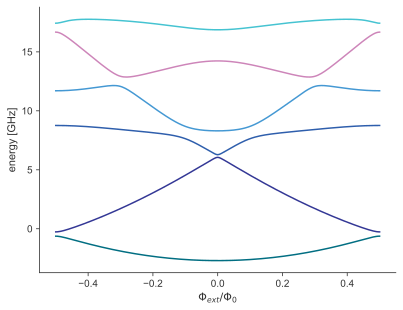

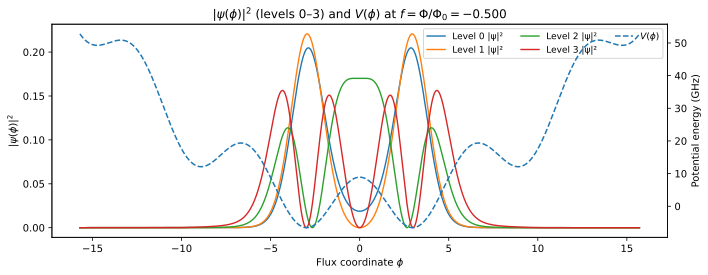

In [42]:
EJ = 8.9
EC = 2.5
EL = 0.5
cutoff = 50

# ----- Wavefunctions & potential in one figure with twin y-axes -----
levels_to_plot = [0, 1, 2, 3] # first 4 levels
flux_show = -0.5 # choose the flux to visualize

fluxonium = scq.Fluxonium(EJ=EJ, EC=EC, EL=EL, flux=0.0, cutoff=cutoff)

# (optional) spectrum sweep you already had
flux_vals = np.linspace(-0.5, 0.5, 201)
fluxonium.plot_evals_vs_paramvals(param_name="flux", param_vals=flux_vals)
fluxonium.set_params(flux=flux_show)

# Diagonalize once and reuse
evals, evecs = fluxonium.eigensys(evals_count=max(levels_to_plot)+1) # +1 because levels are 0-indexed

# Choose a phase grid (radians)
phi_grid = Grid1d(-5*np.pi, 5*np.pi, 1601)

# Collect |psi(φ)|^2 for each level
phi_vals = None
densities = []
for k in levels_to_plot:
    wf = fluxonium.wavefunction(esys=(evals, evecs), which=k, phi_grid=phi_grid)
    if phi_vals is None:
        phi_vals = wf.basis_labels          # φ grid (radians)
    densities.append(np.abs(wf.amplitudes)**2)

# Potential (GHz) on same φ-grid
V_phi = fluxonium.potential(phi_vals)       # GHz if EJ, EL are in GHz

# ---- Plot: left axis for densities, right axis for potential ----
fig, ax = plt.subplots(figsize=(10, 4))

for k, dens in zip(levels_to_plot, densities):
    ax.plot(phi_vals, dens, lw=1.4, label=f"Level {k} |ψ|²")

ax.set_xlabel(r"Flux coordinate $\phi$")
ax.set_ylabel(r"$|\psi(\phi)|^2$")

ax2 = ax.twinx()
lineV, = ax2.plot(phi_vals, V_phi, linestyle="--", label=r"$V(\phi)$")
ax2.set_ylabel("Potential energy (GHz)")

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + [lineV], l1 + l2, ncol=3, fontsize=9, loc="upper right")

plt.title(rf"$|\psi(\phi)|^2$ (levels 0–3) and $V(\phi)$ at $f=\Phi/\Phi_0={flux_show:.3f}$")
plt.tight_layout()
plt.show()


# Qutip diagonalization

### Methods

In [37]:
# returns eigenvalues and eigenvectors for the fluxonium Hamiltonian given the parameters and cutoff n number and flux point
# cutoff: number of if SHO levels we want the number basis functions for.
def eval_and_evecs(flux,EC,EL,EJ,cutoff):
    a = destroy(cutoff) # anihilation operator for the harmonic oscillator basis
    phi = (2*EC/EL)**(1/4)*(a.dag() + a) # using EL as the inductance. Could be EJ but doesn't matter 
    charge = (1j/2)*(EL/(2*EC))**(1/4)*(a.dag() - a)

    H = 4*EC*charge**2 + 0.5*EL*phi**2 - EJ*(phi - 2*np.pi*flux*qeye(cutoff)).cosm()
    evals, ekets = H.eigenstates()
    return evals, ekets

# Return a (cutoff, M) array with HO eigenfunctions varphi_n(phi) along rows (evaluated at M phi points)
# M is the number of phi points, and cutoff is the number of HO levels we want to get the number basis functions for.
def ho_phi_basis(phi_vals, cutoff, phi0):
    u = phi_vals / phi0 # dimensionless coordinate
    gauss = np.exp(-0.5 * u**2) / (np.pi**0.25 * np.sqrt(phi0)) # gaussian prefactor for the HO wavefunctions

    H = np.zeros((cutoff, phi_vals.size)) # rows are different hermite polynomials
    H[0,:] = 1.0 # first row is just the constant function (H_0) for N = 0
    if cutoff > 1: # means we have more than 1 basis function we want
        H[1] = 2.0 * u # vector of length M = len(phi_vals)
        for n in range(1, cutoff-1):
            H[n+1] = 2.0*u*H[n] - 2.0*n*H[n-1] # recursive relation for Hermite polynomials. Doing this vectorized for all phi_vals at once.
    norm = 1.0 / np.sqrt((2.0**np.arange(cutoff)) * factorial(np.arange(cutoff))) # normalization factor for each of the Hermite polynomials. This is a vector of length cutoff.
    return (norm[:, None] * H) * gauss  # (cutoff, M) row i has the HO wavefunction varphi_i(phi) evaluated at all phi_vals. Each row is normalized.

# returns matrix where each row lists the eigenvalues for a flux value cooresponding to the row index
def eigenvalues_vs_flux(evals_count, flux_vals, EC, EL, EJ, cutoff):
    evals_mat = np.empty((len(flux_vals), evals_count)) # eigenvalues for each flux value, for the first 6 levels
    for i, flux in enumerate(flux_vals):
        evals, ekets = eval_and_evecs(flux, EC, EL, EJ, cutoff)
        evals_mat[i, :] = np.real(evals[0:evals_count]) # get the first 6 eigenvalues
    return evals_mat

### Parameters

In [38]:
EJ = 8.9
EC = 2.5
EL = 0.5
cutoff = 50 # number of levels in the harmonic oscillator basis to use for the number basis functions

phi_zpf = (2*EC/EL)**0.25            # <-- use EL here since that is what we used in eval_and_evects when defining phi and charge
phi0    = np.sqrt(2.0) * phi_zpf     # standard HO width used in Hermite formula

### Eigenvalues vs Flux

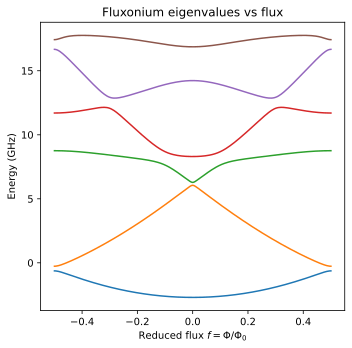

In [39]:
evals_count = 6
flux_vals = np.linspace(-0.5, 0.5, 201)

evals_mat = eigenvalues_vs_flux(evals_count, flux_vals, EC, EL, EJ, cutoff)

plt.figure(figsize=(5, 5))
plt.plot(flux_vals, evals_mat)
plt.xlabel(r"Reduced flux $f=\Phi/\Phi_0$")
plt.ylabel("Energy (GHz)")
plt.title("Fluxonium eigenvalues vs flux")
plt.tight_layout()
plt.show()


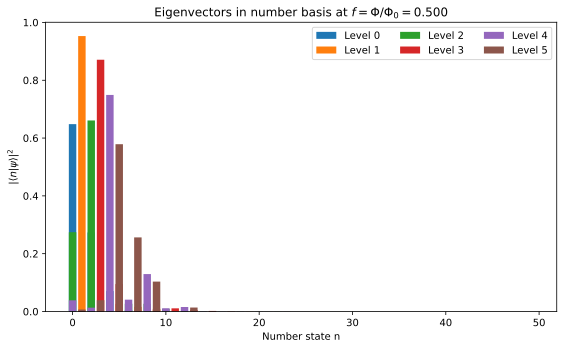

In [45]:
flux_show = .5
evals_count = 6

# diagonalize H at that flux
evals_show, ekets_show = eval_and_evecs(flux_show, EC, EL, EJ, cutoff)

n = np.arange(cutoff) # number states from 0 to cutoff-1
plt.figure(figsize=(8, 5))
for level in range(evals_count): # goes to evals_count-1
    # Coeffs in number basis; |<n|psi>|^2 
    coeffs = ekets_show[level].full().ravel() # convert coefficents to 1D array
    probs = np.abs(coeffs)**2 # modulus squared to get probabilities
    plt.bar(n, probs, lw=1.5, label=f"Level {level}")

plt.xlabel("Number state n")
plt.ylabel(r"$|\langle n|\psi\rangle|^2$")
plt.title(fr"Eigenvectors in number basis at $f=\Phi/\Phi_0 = {flux_show:.3f}$")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()


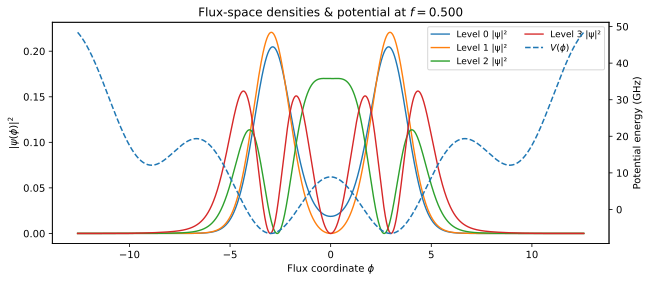

In [46]:
flux_show = 0.5
levels_to_plot = 4
phi_max  = 5 * phi0 # range wide enough for low-lying states

# diagonalize H at that flux
evals_show, ekets_show = eval_and_evecs(flux_show, EC, EL, EJ, cutoff)

# Build flux grid and basis functions
phi_discrete = np.linspace(-phi_max, phi_max, 2001) # length is M
basis_phi = ho_phi_basis(phi_discrete, cutoff, phi0)  # shape (cutoff, M)

# Convert first few eigenstates to flux-coordinate wavefunctions
psi_phi = []
for k in range(levels_to_plot):
    coeffs = ekets_show[k].full().ravel()        # c_n
    psi_k_phi = basis_phi.T @ coeffs             # Σ_n c_n ϕ_n(φ), shape (M,). This is matrix multiplication to do the sum
    psi_phi.append(psi_k_phi)

fig, ax = plt.subplots(figsize=(10, 4))

# Left y-axis: probability densities
for k in range(levels_to_plot):
    ax.plot(phi_discrete, np.abs(psi_phi[k])**2, lw=1.4, label=f"Level {k} |ψ|²")
ax.set_xlabel(r"Flux coordinate $\phi$")
ax.set_ylabel(r"$|\psi(\phi)|^2$")

# Right y-axis: potential energy in frequency units (GHz if EC/EJ/EL in GHz)
ax2 = ax.twinx()
V_phi = 0.5*EL*phi_discrete**2 - EJ*np.cos(phi_discrete - 2*np.pi*flux_show)  # GHz
line_V, = ax2.plot(phi_discrete, V_phi, linestyle='--', label=r"$V(\phi)$")
ax2.set_ylabel("Potential energy (GHz)")

# One combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + [line_V], l1 + l2, ncol=2, fontsize=9, loc="upper right")

plt.title(fr"Flux-space densities & potential at $f =  {flux_show:.3f}$")
plt.show()
